In [ ]:
import pandas as pd
import numpy as np
import importlib
# ruff: noqa: E402
import app.risk.risk_metrics
importlib.reload(app.risk.risk_metrics)
from app.risk.risk_metrics import RiskMetrics

In [104]:
# create dummy test df
def sample_returns():
    np.random.seed(0)
    size = 252*5 # 5 years
    dates = pd.date_range(start="2024-01-01", periods=size, freq="D")
    data = {
        "Asset_A": np.random.normal(0, 0.01, size=size),
        "Asset_B": np.random.normal(0, 0.015, size=size),
    }
    return pd.DataFrame(data, index=dates)

In [105]:
df = sample_returns()

risk_metrics = RiskMetrics(df=df, lookback_period=252)

In [106]:
#risk_metrics.compute_var()
risk_metrics.backtest_var()

{'Asset_A': {'Number of breaches': np.int64(49),
  'Expected breaches': 50.350000000000044,
  'Breach rate': np.float64(0.04865938430983118),
  'Number of observations': 1007},
 'Asset_B': {'Number of breaches': np.int64(55),
  'Expected breaches': 50.350000000000044,
  'Breach rate': np.float64(0.05461767626613704),
  'Number of observations': 1007}}

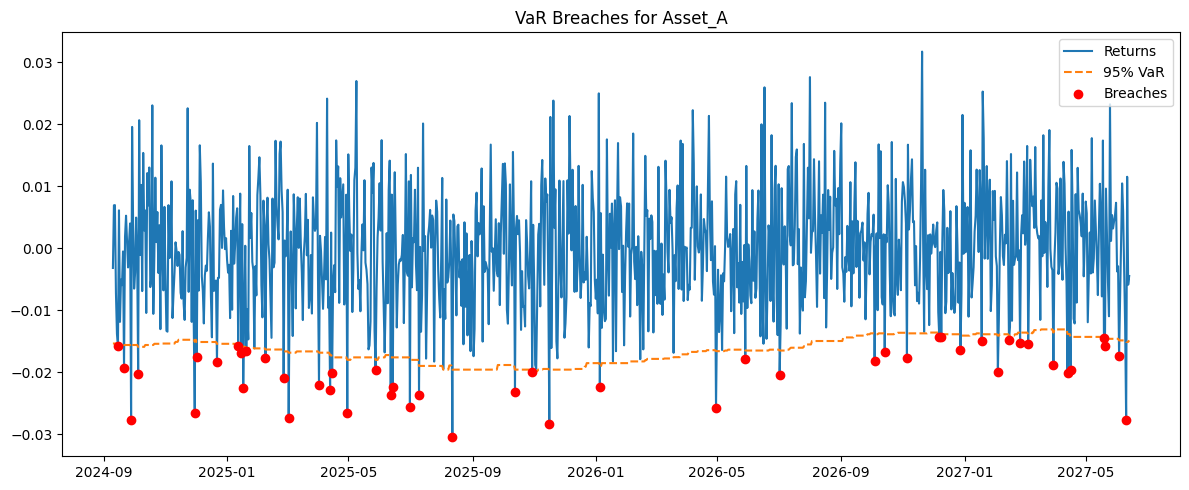

In [107]:
risk_metrics.plot_var_breaches('Asset_A')

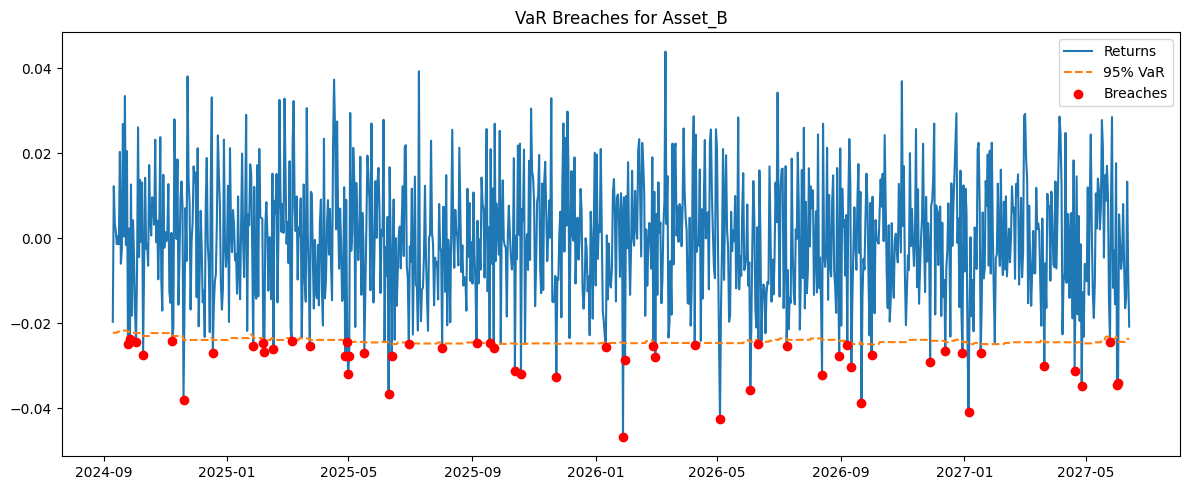

In [108]:
risk_metrics.plot_var_breaches('Asset_B')